# US Accidents Analysis (2016-2023)

**Author:** Ibrahim  
**Environment:** Google Colab / Python 3

## Overview
This project analyses a large‑scale dataset of traffic accidents in the United States from 2016 to 2023. It examines temporal patterns (year, month, day, hour), weather impacts, severity distribution, and geographic hotspots. The insights help understand peak accident times, hazardous conditions, and high‑risk areas.

## Dataset
- **Source:** Kaggle – US Accidents (2016-2023)
- **Rows:** ~2.5 million (we sample 200,000 for speed)
- **Columns:** Start_Time, Severity, Weather_Condition, Temperature, City, State, Latitude, Longitude

## Key Steps
1. Load and sample data
2. Parse datetime fields
3. Explore temporal patterns
4. Analyse weather and severity
5. Visualise geographic distribution

## Requirements
- pandas, matplotlib, seaborn, numpy

---

**© 2026 Ibrahim – Traffic accident analytics.**

### Install & Imports

In [1]:
!pip install -q pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Load Dataset (with sampling)

In [5]:
import pandas as pd
import numpy as np
from datetime import datetime

# Exact path from the Kaggle input directory
file_path = "/kaggle/input/datasets/sobhanmoosavi/us-accidents/US_Accidents_March23.csv"

# Load only 200,000 rows for faster processing
df = pd.read_csv(file_path, nrows=200000)

print(f"Loaded {len(df)} accident records.")
print("First 2 rows:")
print(df.head(2))

# Basic data cleaning
# Convert Start_Time to datetime
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['Year'] = df['Start_Time'].dt.year
df['Month'] = df['Start_Time'].dt.month
df['Hour'] = df['Start_Time'].dt.hour
df['DayOfWeek'] = df['Start_Time'].dt.dayofweek

# Drop rows with missing critical columns
df_clean = df.dropna(subset=['Severity', 'Weather_Condition', 'Start_Time'])
print(f"Rows after cleaning: {len(df_clean)}")

Loaded 200000 accident records.
First 2 rows:
    ID   Source  Severity           Start_Time             End_Time  \
0  A-1  Source2         3  2016-02-08 05:46:00  2016-02-08 11:00:00   
1  A-2  Source2         2  2016-02-08 06:07:59  2016-02-08 06:37:59   

   Start_Lat  Start_Lng  End_Lat  End_Lng  Distance(mi)  ... Roundabout  \
0  39.865147 -84.058723      NaN      NaN          0.01  ...      False   
1  39.928059 -82.831184      NaN      NaN          0.01  ...      False   

  Station   Stop Traffic_Calming Traffic_Signal Turning_Loop Sunrise_Sunset  \
0   False  False           False          False        False          Night   
1   False  False           False          False        False          Night   

  Civil_Twilight Nautical_Twilight Astronomical_Twilight  
0          Night             Night                 Night  
1          Night             Night                   Day  

[2 rows x 46 columns]
Rows after cleaning: 197212


### Data Cleaning & Feature Extraction

In [6]:
# Convert Start_Time to datetime
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['Year'] = df['Start_Time'].dt.year
df['Month'] = df['Start_Time'].dt.month
df['Hour'] = df['Start_Time'].dt.hour
df['DayOfWeek'] = df['Start_Time'].dt.dayofweek  # Monday=0, Sunday=6

# Drop rows with missing critical columns
df_clean = df.dropna(subset=['Severity', 'Weather_Condition', 'Start_Time'])
print(f"Rows after cleaning: {len(df_clean)}")

Rows after cleaning: 197212


### Accidents by Year

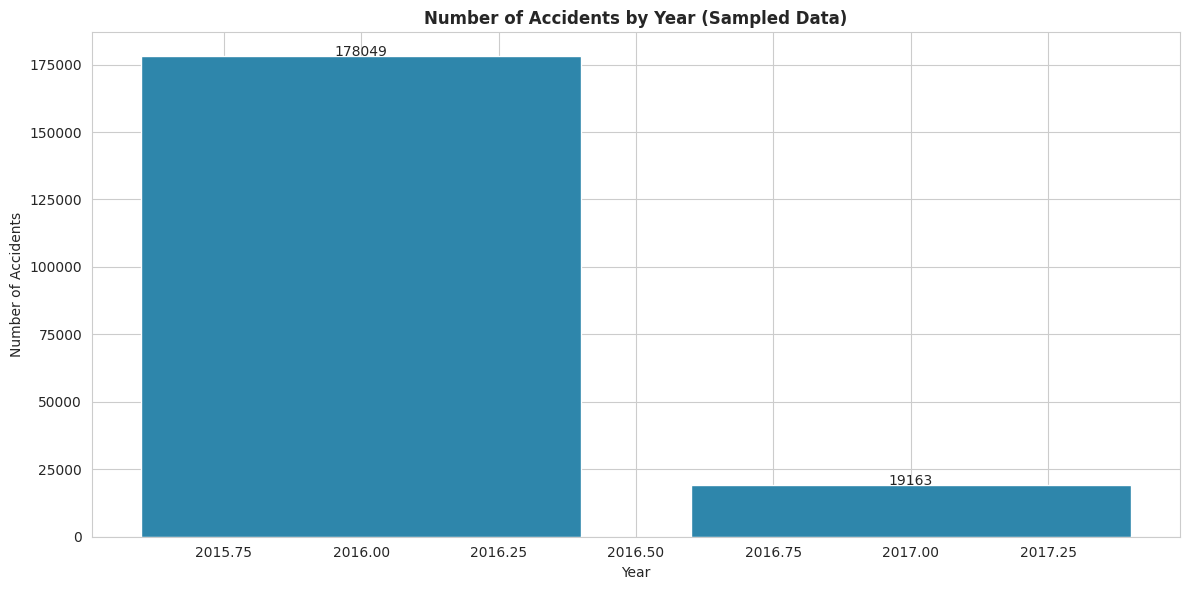

In [7]:
year_counts = df_clean['Year'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(year_counts.index.astype(int), year_counts.values, color='#2E86AB')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.title('Number of Accidents by Year (Sampled Data)', fontweight='bold')
for i, v in enumerate(year_counts.values):
    plt.text(year_counts.index[i], v + 50, str(v), ha='center')
plt.tight_layout()
plt.show()

### Accidents by Hour of Day

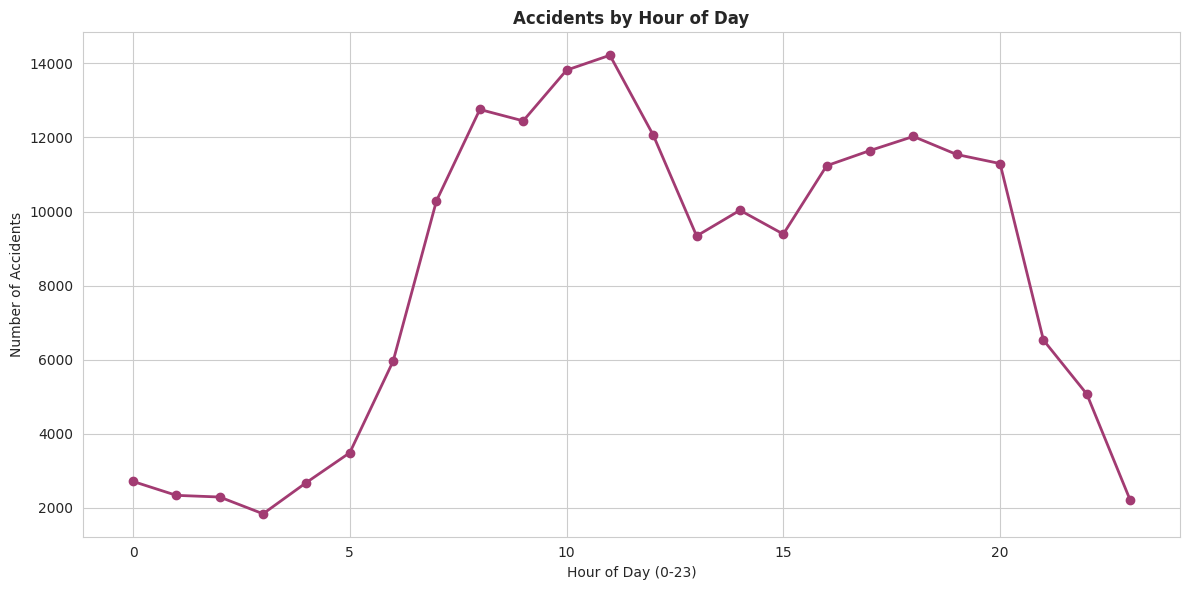

In [8]:
hour_counts = df_clean['Hour'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(hour_counts.index, hour_counts.values, marker='o', linewidth=2, color='#A23B72')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Accidents')
plt.title('Accidents by Hour of Day', fontweight='bold')
plt.grid(True)
plt.tight_layout()
plt.show()

### Top 10 Cities with Most Accidents

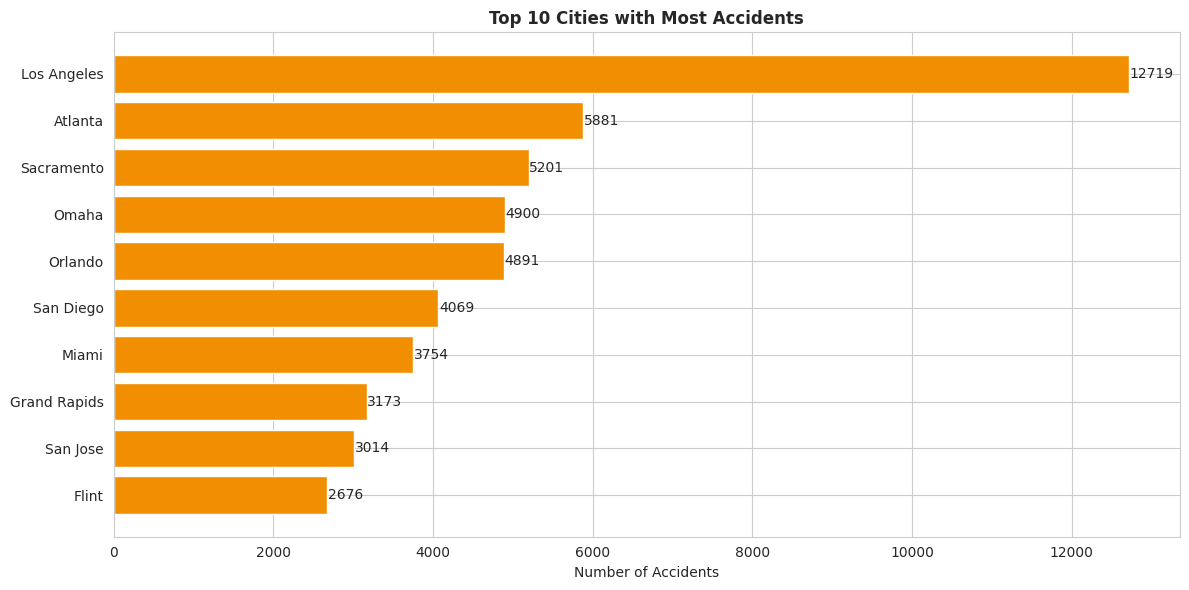

In [9]:
top_cities = df_clean['City'].value_counts().head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_cities.index[::-1], top_cities.values[::-1], color='#F18F01')
plt.xlabel('Number of Accidents')
plt.title('Top 10 Cities with Most Accidents', fontweight='bold')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2, f'{int(width)}', va='center')
plt.tight_layout()
plt.show()

### Weather Condition Impact

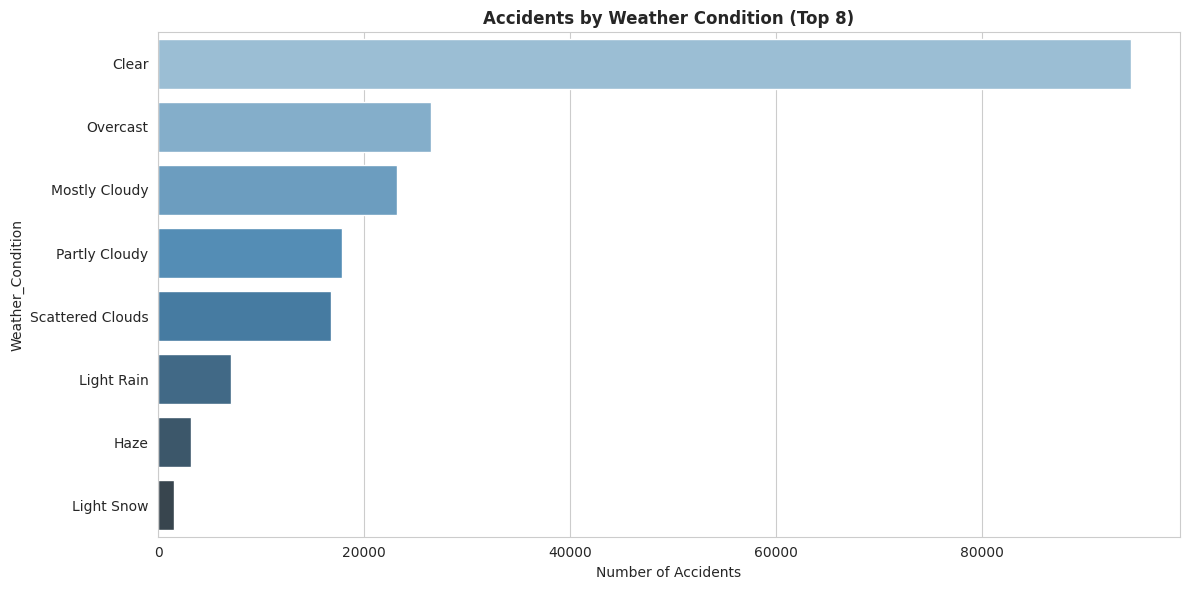

In [11]:
top_weather = df_clean['Weather_Condition'].value_counts().head(8)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_weather.values, y=top_weather.index, palette='Blues_d')
plt.xlabel('Number of Accidents')
plt.title('Accidents by Weather Condition (Top 8)', fontweight='bold')
plt.tight_layout()
plt.show()

### Temperature Distribution During Accidents

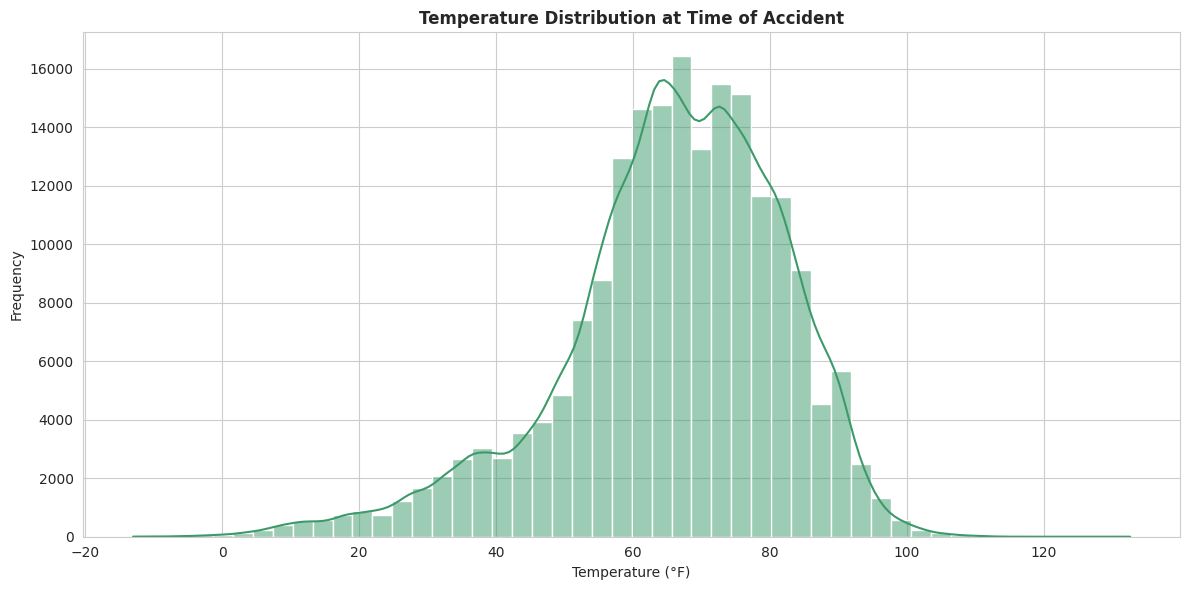

In [12]:
plt.figure(figsize=(12, 6))
sns.histplot(df_clean['Temperature(F)'].dropna(), bins=50, kde=True, color='#3C9A6A')
plt.xlabel('Temperature (°F)')
plt.ylabel('Frequency')
plt.title('Temperature Distribution at Time of Accident', fontweight='bold')
plt.tight_layout()
plt.show()

### Accidents by Month

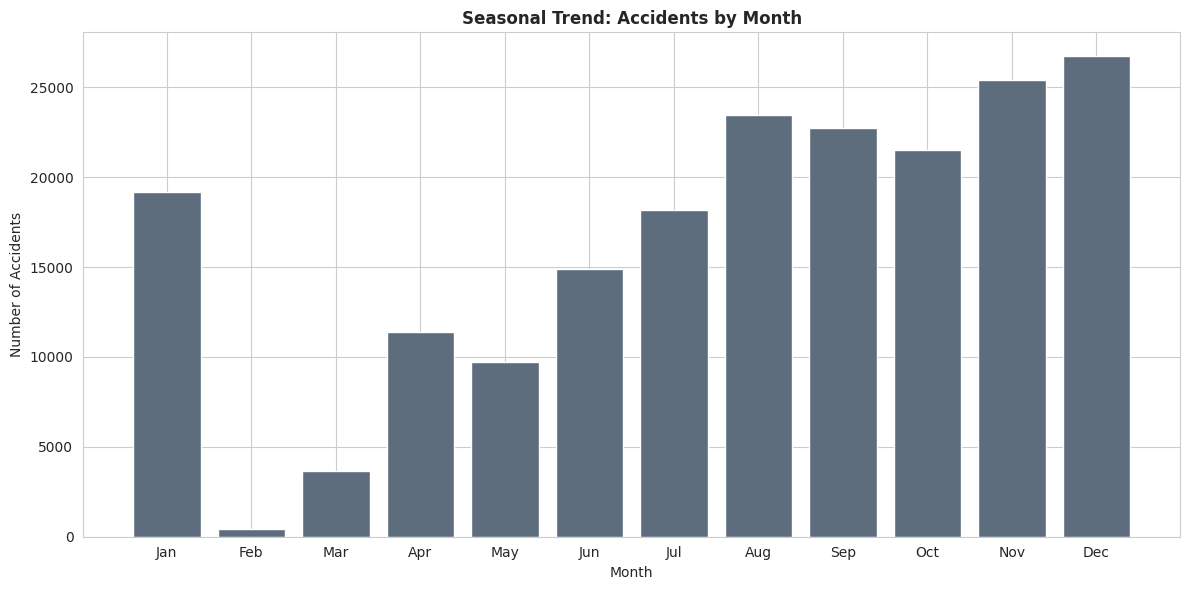

In [13]:
month_counts = df_clean['Month'].value_counts().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 6))
plt.bar(month_names, month_counts.values, color='#5D6D7E')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.title('Seasonal Trend: Accidents by Month', fontweight='bold')
plt.tight_layout()
plt.show()

### Day of Week vs Severity (Heatmap)

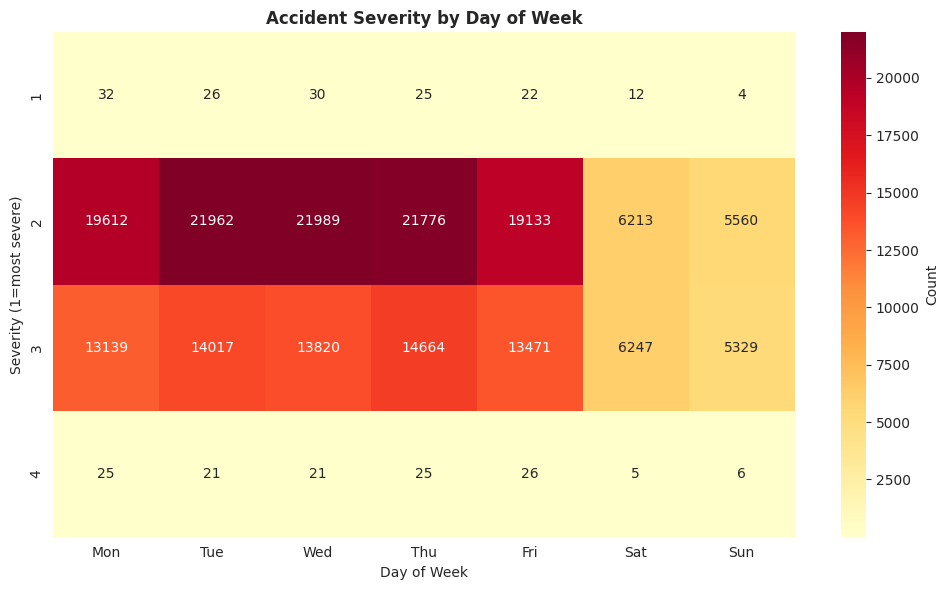

In [14]:
# Pivot table: rows=Severity, columns=DayOfWeek (count)
severity_dow = pd.crosstab(df_clean['Severity'], df_clean['DayOfWeek'])
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(10, 6))
sns.heatmap(severity_dow, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Count'})
plt.title('Accident Severity by Day of Week', fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Severity (1=most severe)')
plt.xticks(ticks=np.arange(7)+0.5, labels=dow_labels)
plt.tight_layout()
plt.show()

### Hazardous Weather Conditions (Top 10)

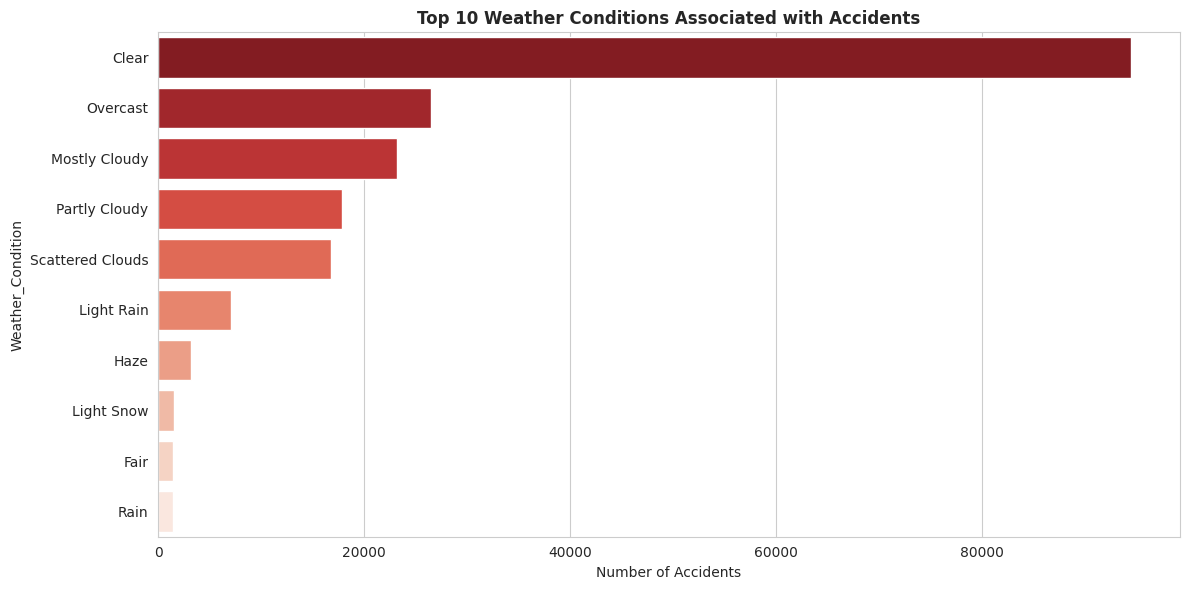

In [15]:
hazardous = df_clean['Weather_Condition'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=hazardous.values, y=hazardous.index, palette='Reds_r')
plt.xlabel('Number of Accidents')
plt.title('Top 10 Weather Conditions Associated with Accidents', fontweight='bold')
plt.tight_layout()
plt.show()

### Geographic Scatter (Sample)

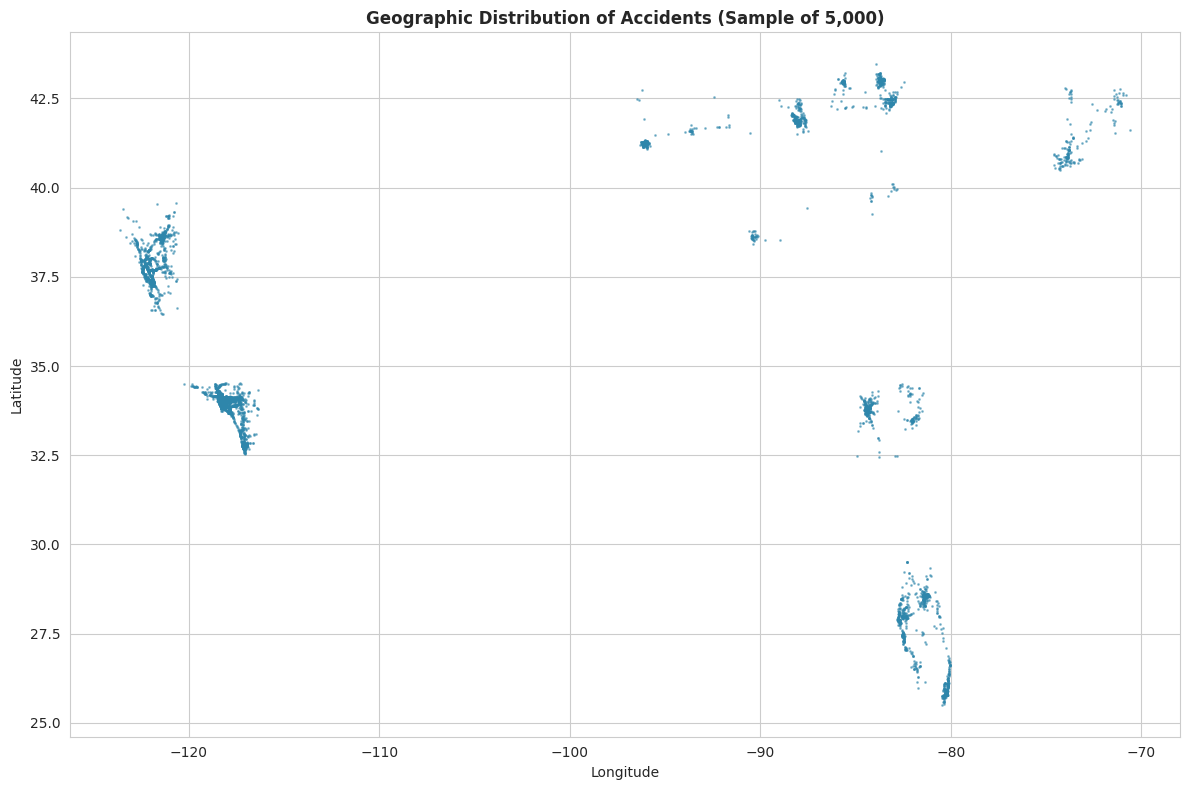

In [16]:
# Sample 5000 points for scatter plot (avoid overcrowding)
geo_sample = df_clean[['Start_Lat', 'Start_Lng']].dropna().sample(n=5000, random_state=42)

plt.figure(figsize=(12, 8))
plt.scatter(geo_sample['Start_Lng'], geo_sample['Start_Lat'], s=1, alpha=0.5, c='#2E86AB')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of Accidents (Sample of 5,000)', fontweight='bold')
plt.tight_layout()
plt.show()

### Key Insights Summary

In [17]:
print(" Key Insights from US Accidents Analysis")
print(f" Accident records analysed: {len(df_clean):,}")
peak_hour = hour_counts.idxmax()
print(f" Peak accident hour: {peak_hour}:00 ({hour_counts.max()} accidents in sample)")
print(f" Top city for accidents: {top_cities.index[0]} ({top_cities.iloc[0]} accidents)")
print(f" Most common weather during accident: {top_weather.index[0]}")
print(f" Month with most accidents: {month_names[month_counts.idxmax()-1]}")
print(" Recommendations: Improve signage during peak hours, enhance weather alerts.")

 Key Insights from US Accidents Analysis
 Accident records analysed: 197,212
 Peak accident hour: 11:00 (14220 accidents in sample)
 Top city for accidents: Los Angeles (12719 accidents)
 Most common weather during accident: Clear
 Month with most accidents: Dec
 Recommendations: Improve signage during peak hours, enhance weather alerts.


### Final Summary

In [18]:
print("US Accidents Analysis - COMPLETED")
print("Author: Ibrahim")
print("Dataset loaded and cleaned.")
print("Temporal, weather, and geographic patterns identified.")
print("Visualisations ready for presentation or dashboard.")

US Accidents Analysis - COMPLETED
Author: Ibrahim
Dataset loaded and cleaned.
Temporal, weather, and geographic patterns identified.
Visualisations ready for presentation or dashboard.
